# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "sparse-reg" #"prim-Na-EE-vir" #"full-reg-vir" #"act-reg-exp-reg" # mem-reg full_nobl-reg
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,harm_pI,T_min_pI,harm_pS,max_pM_fold,max_pE_fold,T_pM_min,T_max_pI,T_pE_start,T_pE_max,stim_pI,stim_pH,stim_pP,min_pS,antigenicity_over_harm,T_pE_clear,harm_pI_noprotection,peff_protection,peff_toxicity,peff_utility
0,0.000000e+00,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.000000e+00,0.0,0.000000,0.000000,0.693147,0.000000,0.00,20.000000,0.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.00,0.000000,0.000000,0.000000,0.000000
104,0.000000e+00,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,0.000000e+00,0.0,0.000000,0.000000,0.693147,0.000000,0.00,20.000000,0.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.00,0.000000,0.000000,0.000000,0.000000
208,0.000000e+00,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.000000,0.000000,0.693147,0.000000,0.00,20.000000,0.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.00,0.000000,0.000000,0.000000,0.000000
312,0.000000e+00,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,0.000000e+00,0.0,0.000000,0.000000,0.693147,0.000000,0.00,20.000000,0.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.00,0.000000,0.000000,0.000000,0.000000
416,0.000000e+00,0.01,10000000.0,0.0,10000000.0,300.0,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,0.000000e+00,0.0,0.000000,0.000000,0.693147,0.000000,0.00,20.000000,0.00,0.687795,0.060883,0.000000,9.876119e+06,NaN,0.00,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32304583,1.500000e-07,1.00,1000000.0,1000.0,10000000.0,300.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,4.869644e+06,0.0,329.969366,1.476287,0.711314,2.697246,16.16,8.704133,16.74,0.217995,1.203370,0.001016,5.026024e+06,0.69897,0.58,2.436409,0.001587,0.000165,0.001422
32304687,1.500000e-07,1.00,1000000.0,1000.0,10000000.0,300.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,4.869655e+06,0.0,314.667152,1.495149,0.743523,2.287043,16.16,8.045533,15.77,0.217998,1.203368,0.000983,5.025995e+06,0.69897,-0.39,2.436409,0.001581,0.000157,0.001424
32304791,1.500000e-07,1.00,1000000.0,1000.0,10000000.0,300.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.865819e+06,0.0,661.901856,1.710188,1.128171,5.063829,16.16,9.752033,16.69,0.217771,1.202839,0.002054,5.029785e+06,0.69897,0.53,2.436409,0.003499,0.000331,0.003168
32304895,1.500000e-07,1.00,1000000.0,1000.0,10000000.0,300.0,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,4.810012e+06,0.0,5079.317720,3.507158,3.549138,9.958943,16.16,9.103833,14.98,0.214837,1.194544,0.012658,5.078492e+06,0.69897,-1.18,2.436409,0.031403,0.002540,0.028863


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[0][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inflam.", "Anti-inflam.", "Baseline"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[0][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)

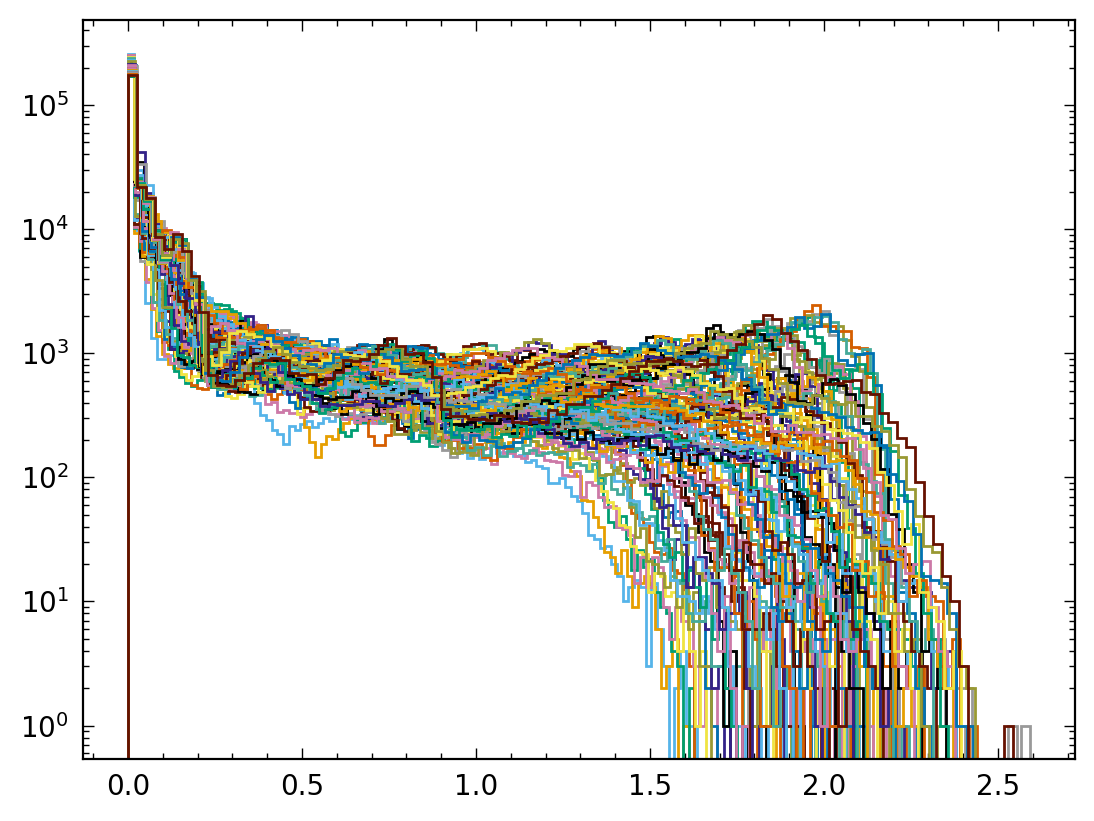

In [4]:
# Inspect distribution of observables
sel = 'stim_pP'
for a in np.unique(clustered_mean_df[key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 12
fevals: 12
fevals: 12
fevals: 79


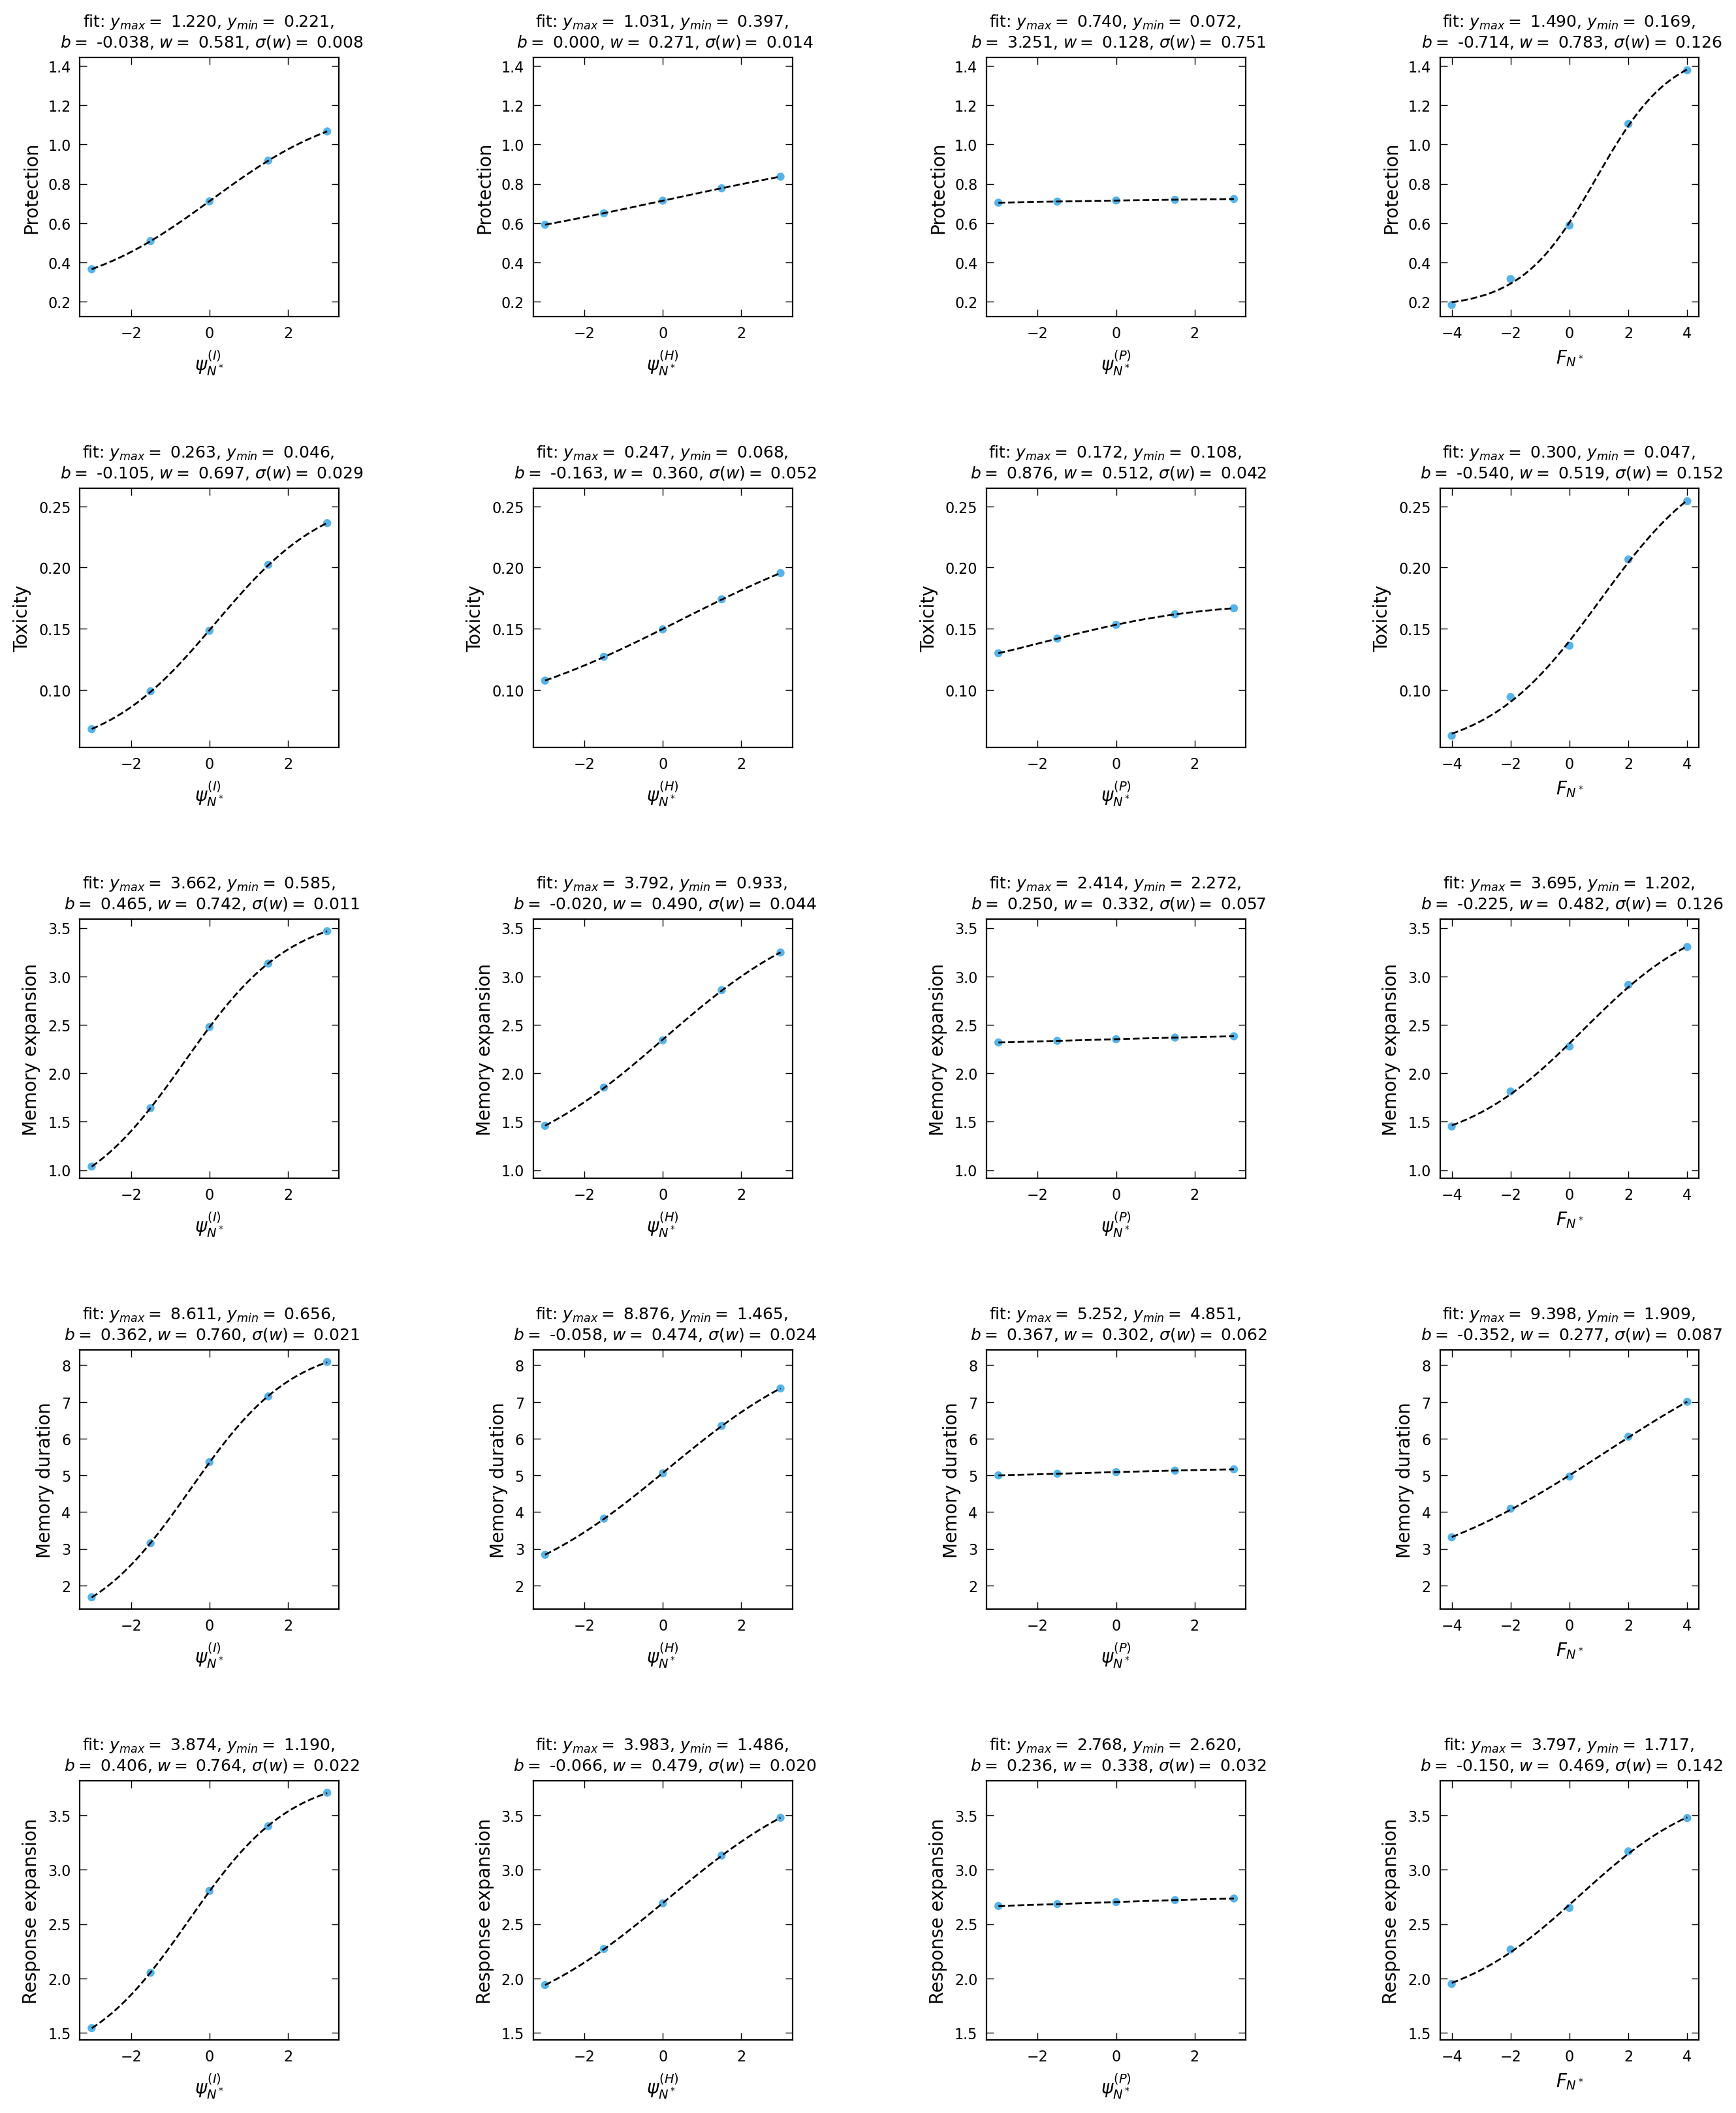

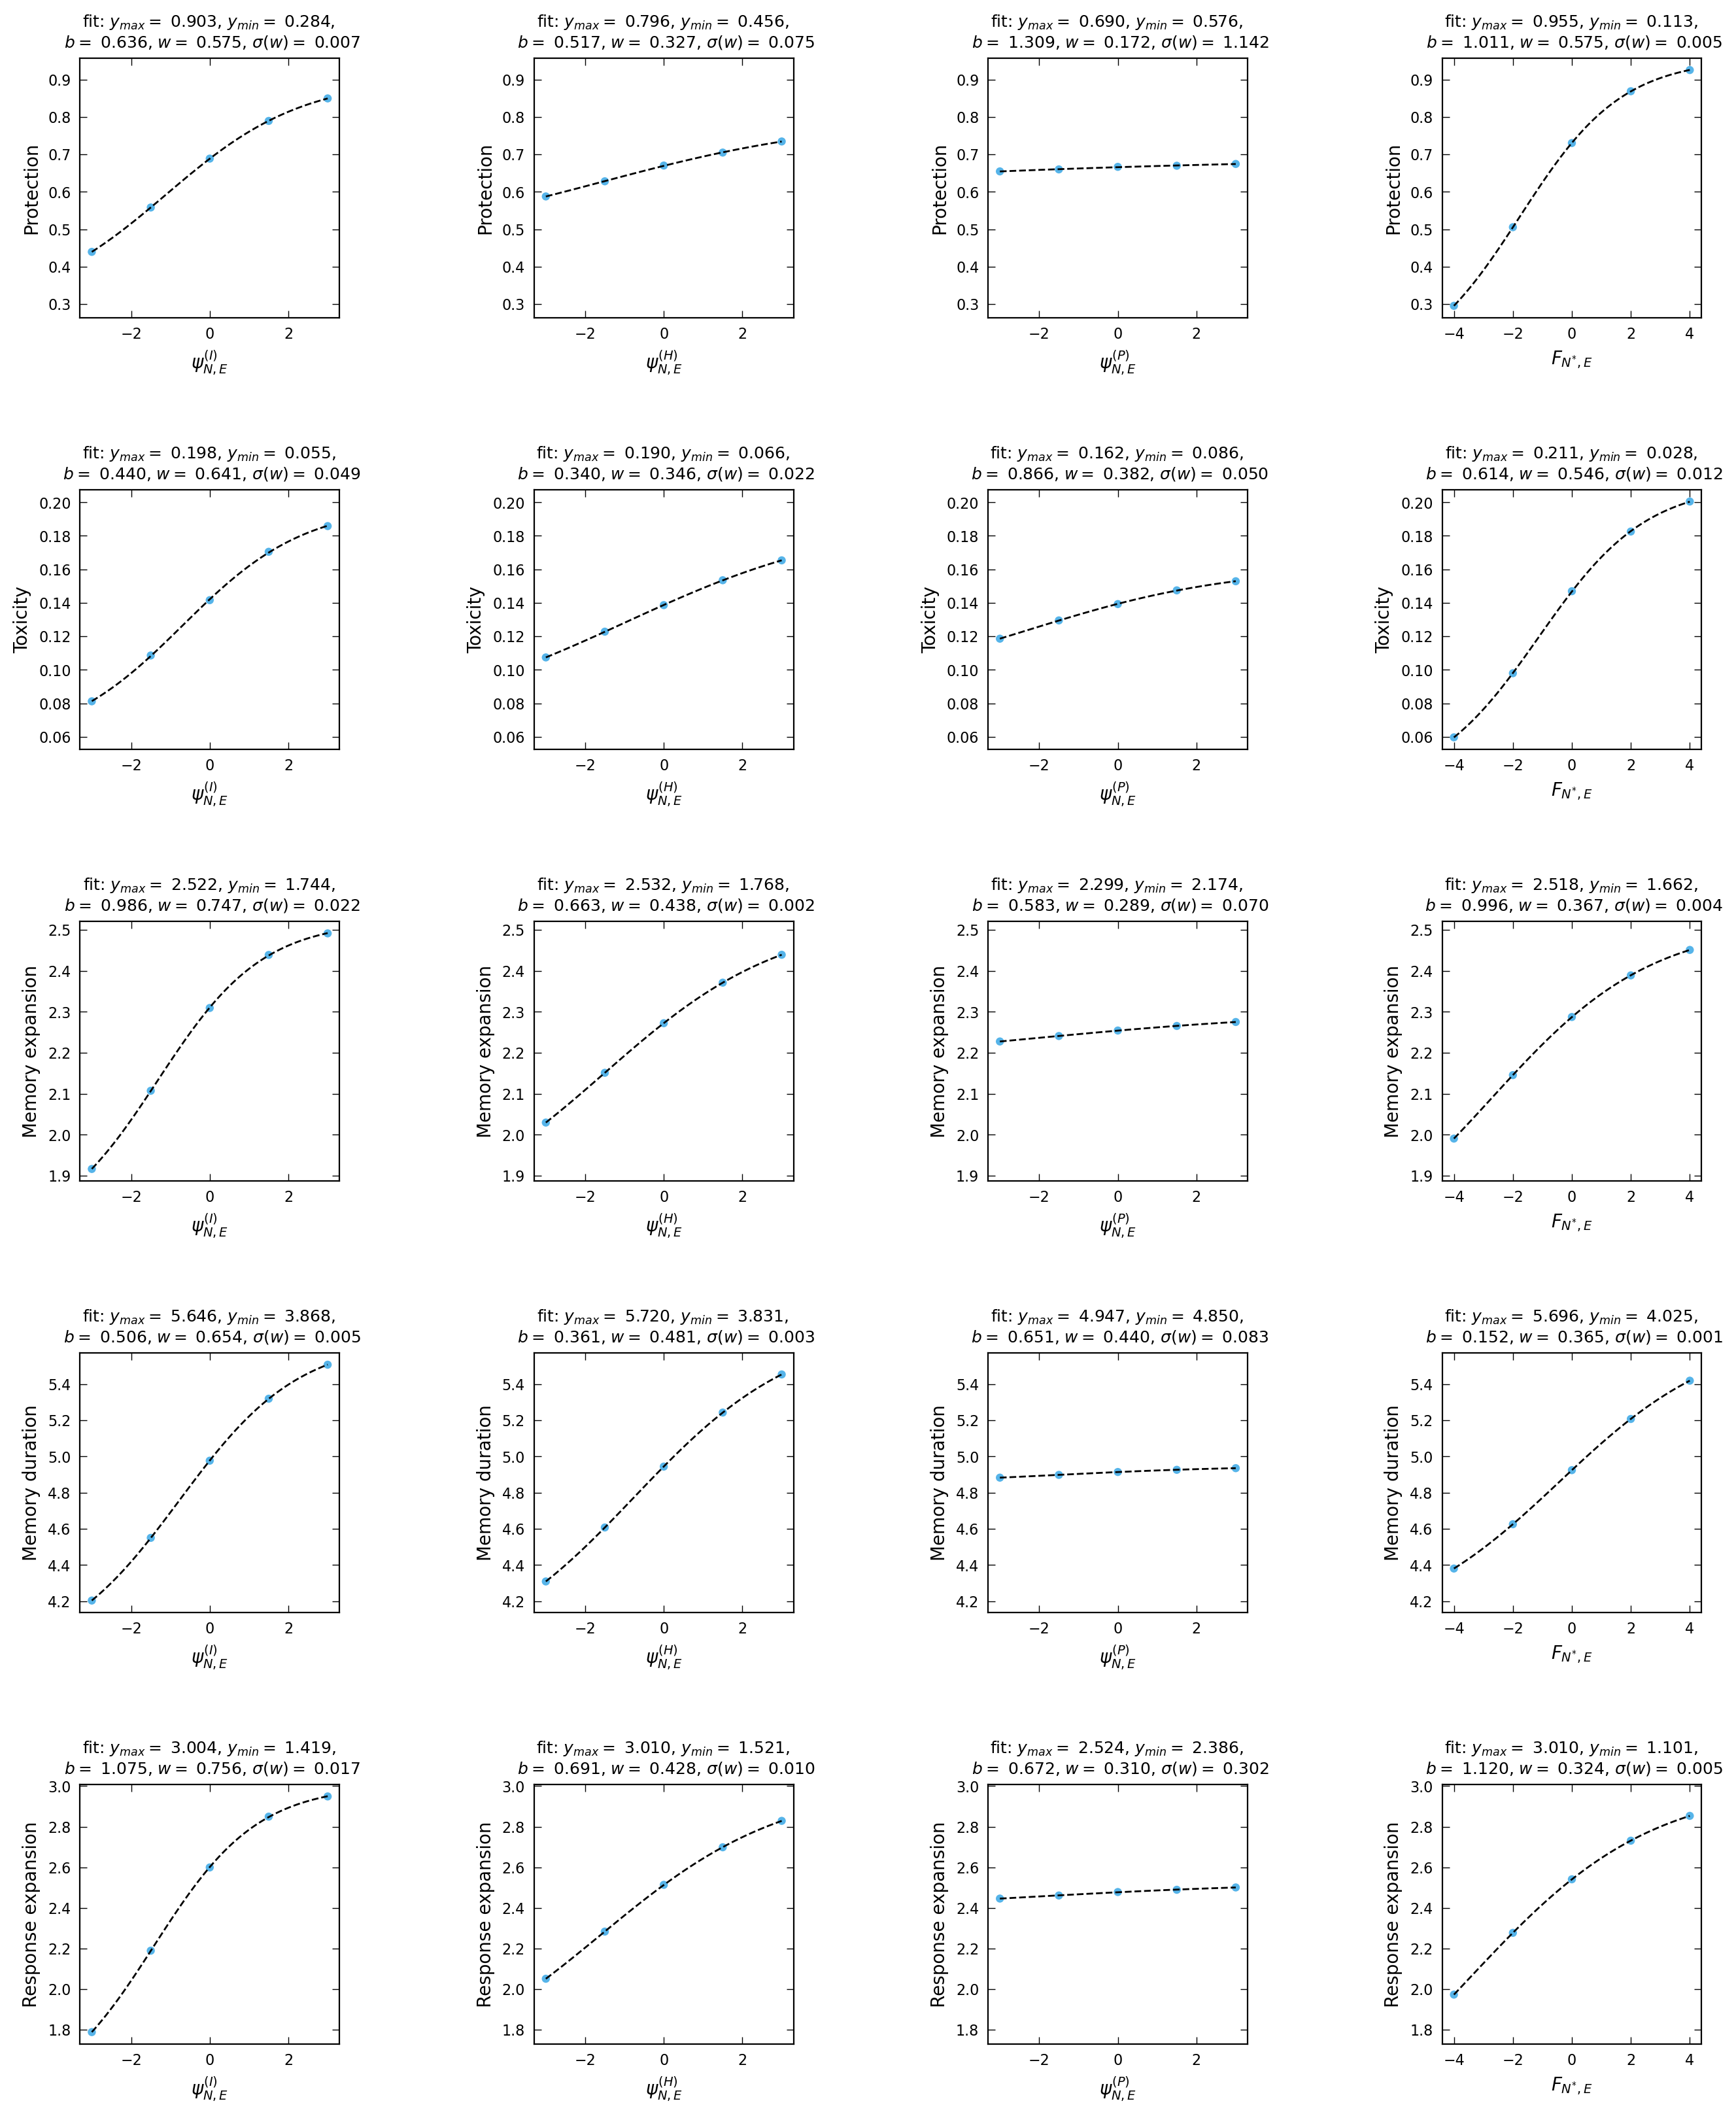

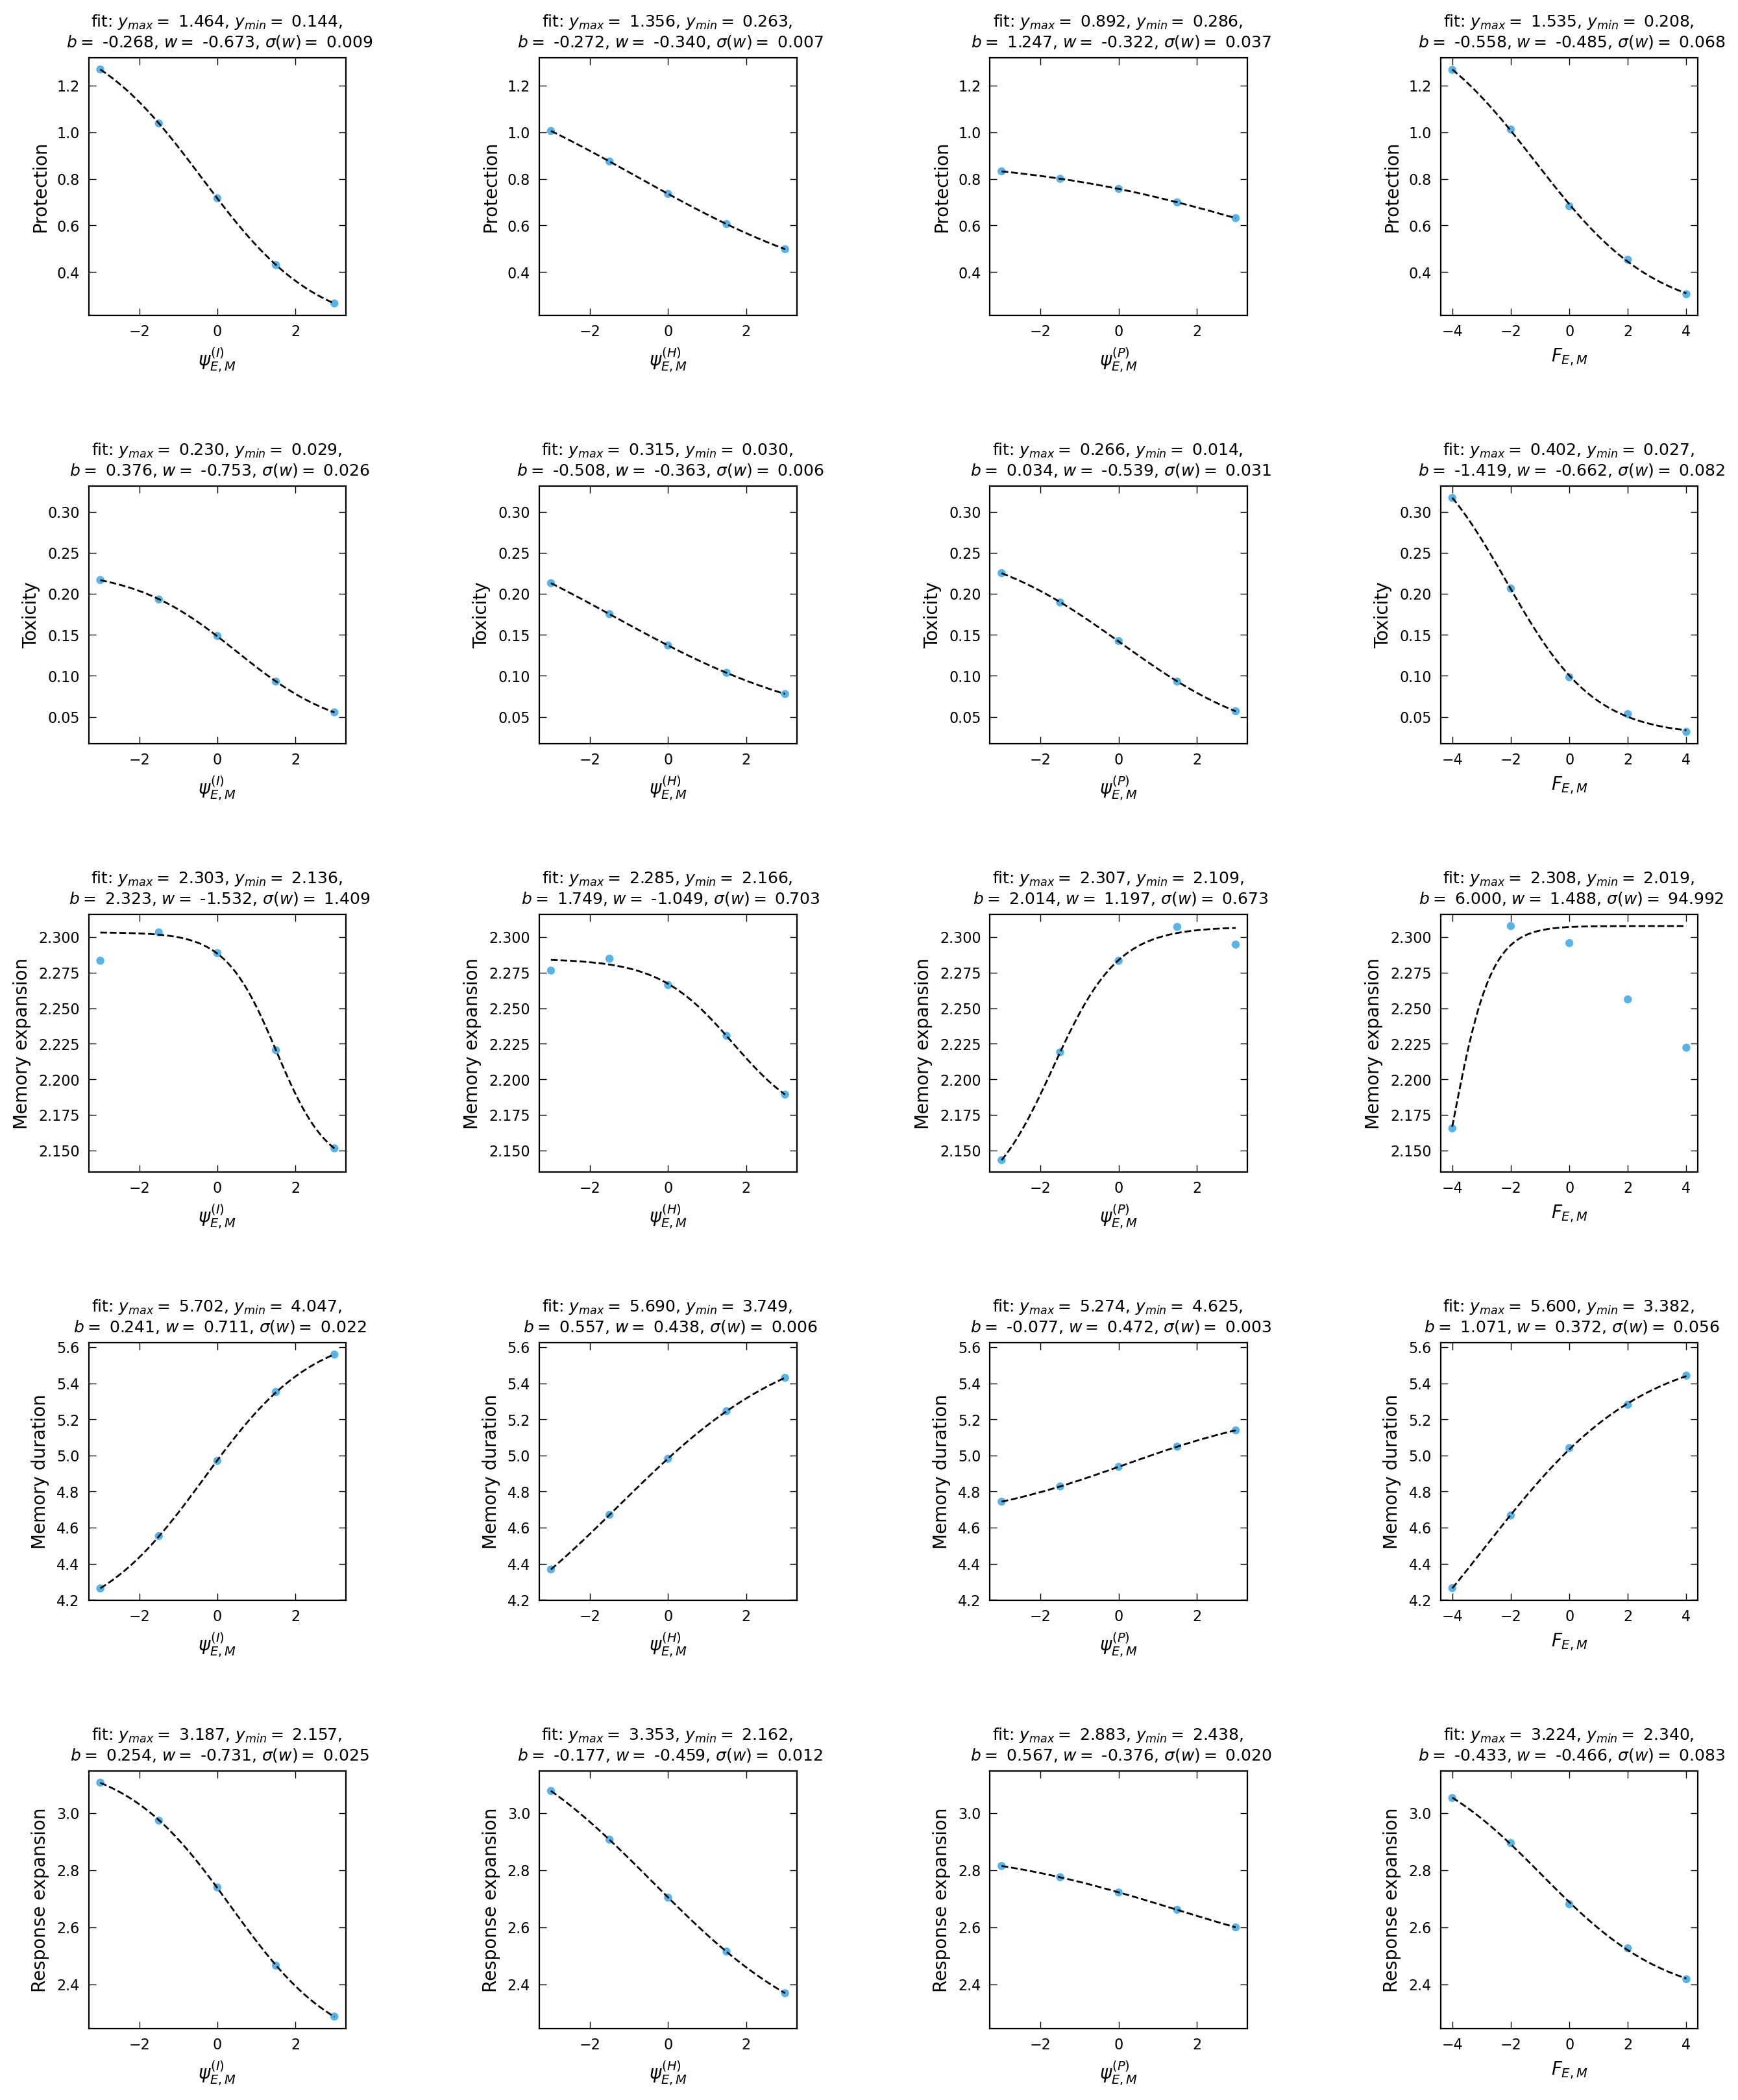

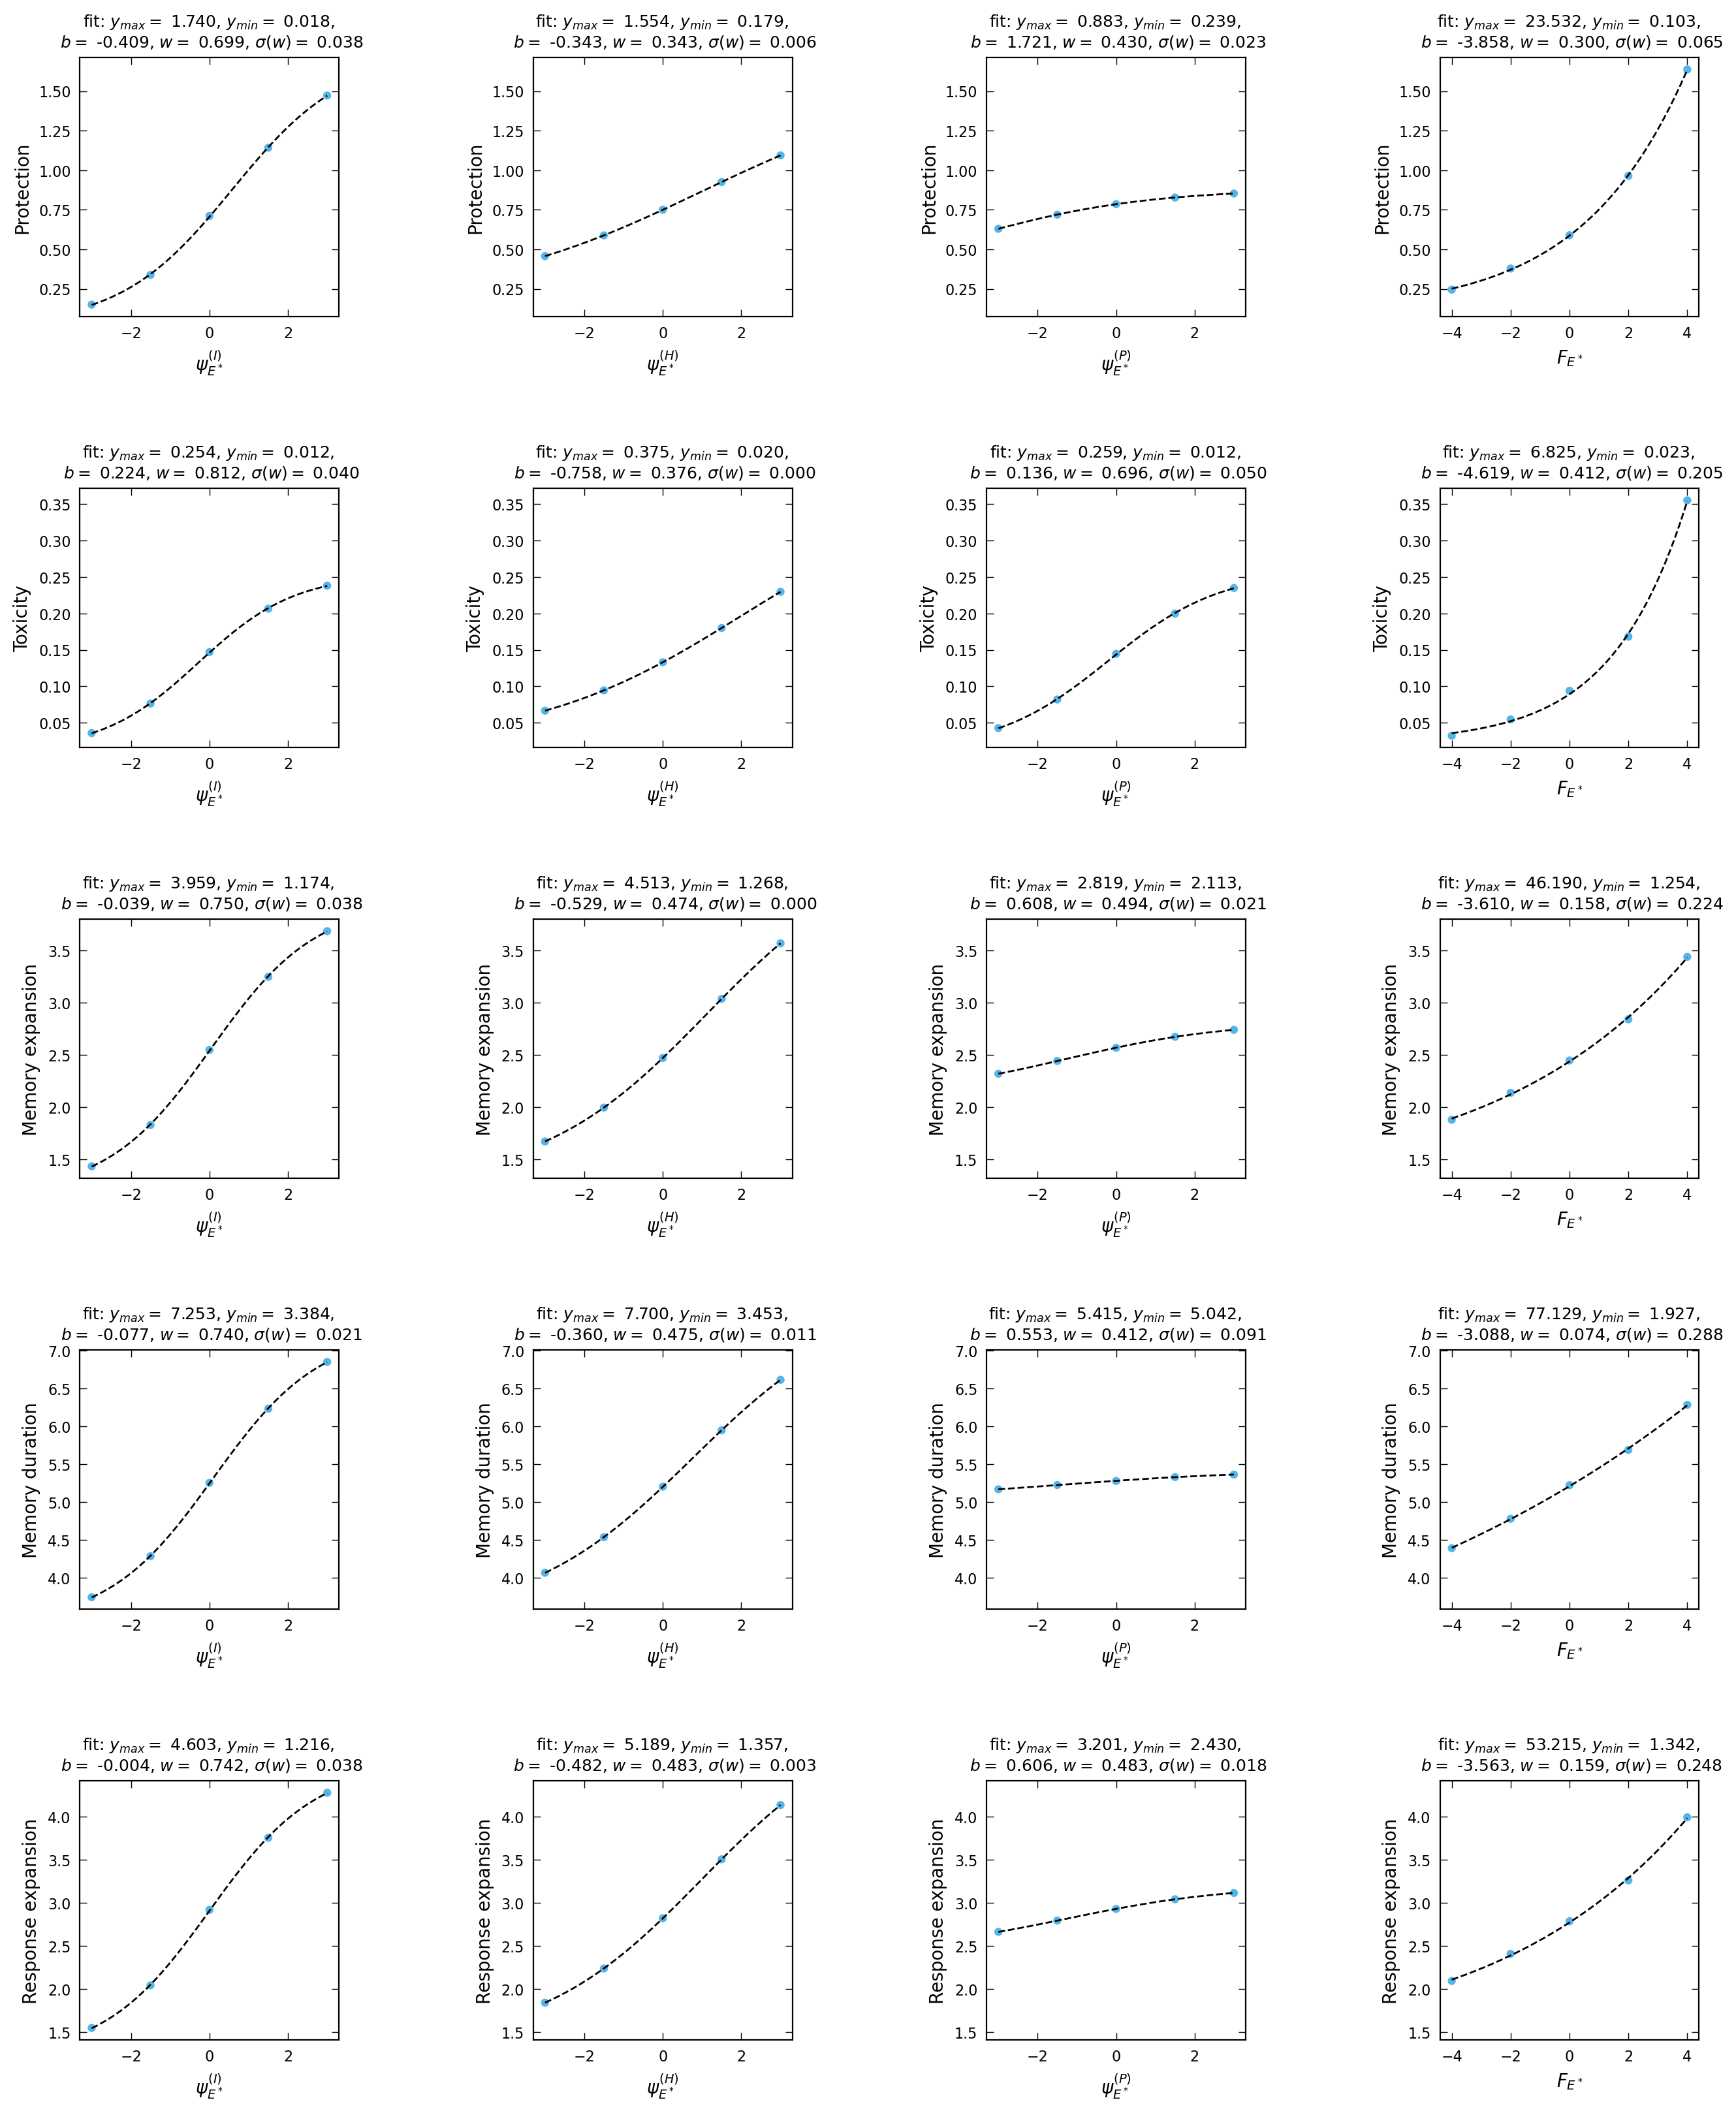

In [5]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

    data = clustered_mean_df.loc[clustered_mean_df.K_EH == K_EH].groupby(reg_choice, as_index = False).mean()
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
                              marker = 'o', s = 20, edgecolors = 'None')

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max, y_min, 0.0, 0.1),
                                   method = 'trf', 
                                   bounds = ([np.max(data_mean[var].values), np.minimum(2*y_min, 0), -2*psi_max, -2*psi_max], [10*y_max if y_max > 0 else 0.0, np.min(data_mean[var].values), 2*psi_max, 2*psi_max]),
                                   maxfev=5000,
                                   full_output = True)
  
            sigma_w = np.sqrt(np.diag(pcov))[-1]

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

            axs[i, j].set_title('fit: $y_{max} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
            axs[i, j].minorticks_off()
            axs[i, j].yaxis.set_tick_params(labelbottom=True)
            axs[i, j].xaxis.set_tick_params(labelbottom=True)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)
            axs[i, j].set_box_aspect(1)
            axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
            axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

        if i == 0:
            print("fevals:", infodict['nfev'])
    
    fig_c.subplots_adjust(wspace=.75, hspace=0.5)
    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
    del data

In [6]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [7]:
# Regress Performance measures on regulation parameters
num_cpu = 104
variables = reg

def model(input, fit = "linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, 0.0 if y_min > 0.0 else y_min] + num_modules*[0.0] + len(variables)*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_min, np.minimum(5*y_min, 0)] + num_modules*[-3.0*F0_max] + len(variables)*[-3.0*F0_max], 
                                     [5*(y_max - y_min) if y_max > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1] + num_modules*[3.0*F0_max] + len(variables)*[3.0*F0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input['stim_pI'].values), 
                                                                                               np.mean(input['stim_pH'].values),
                                                                                               np.mean(input['stim_pP'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_max', 'y_min'] + [('intercept_' + j) for j in modules] \
                            + variables + ['sigma_y_max', 'sigma_y_min'] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + ['sigma_'+r  for r in variables] + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+'-'+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                               columns = ['y_max', 'y_min'] + [('intercept_' + j) for j in modules] \
                            + variables + ['sigma_y_max', 'sigma_y_min'] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + ['sigma_'+r  for r in variables] + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+'-'+'impact_data'+'.pkl')

In [8]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+'-'+'impact_data'+'.pkl')

In [17]:
# View result
perf = 0 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+'-'+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)])

,y_max,y_min,intercept_Na,intercept_NE,intercept_EM,intercept_EE,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,sigma_y_max,sigma_y_min,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
0,4.940656e-324,4.940656e-324,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.01,1.000000e+07,0.000000e+00,50000.0,300.0,10000000.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.672736,0.060883,0.109833,0.999456
5,4.940656e-324,4.940656e-324,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.01,5.000000e+07,0.000000e+00,50000.0,300.0,10000000.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.179787,0.060883,0.034818,0.850787
10,4.940656e-324,4.940656e-324,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.05,1.000000e+07,0.000000e+00,50000.0,300.0,10000000.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.650409,0.267120,0.108675,0.822509
15,4.940656e-324,4.940656e-324,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.05,5.000000e+07,0.000000e+00,50000.0,300.0,10000000.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.172502,0.267120,0.034237,0.700161
20,2.889074e+01,-1.189663e-01,-0.264026,1.654604,-1.443911,-2.720414,1.042410,0.037894,0.002833,1.030658,0.860231,0.044874,0.016256,0.806203,-3.264948,-0.538608,-0.352345,-1.505877,3.523835,0.551746,0.363690,1.766530,0.037016,0.002786,0.003414,0.007733,0.005007,0.011253,0.004241,0.002615,0.002612,0.003267,0.004252,0.003085,0.003082,0.002785,0.010503,0.004200,0.003959,0.004269,0.013262,0.004217,0.003869,0.006232,0.25,1.000000e+04,1.500000e-07,50000.0,300.0,10000000.0,1.275522,28.572932,-0.317803,0.001149,0.0,1.362482,4.327847,5.034261,5.022633,1.724637,0.260520,2.812913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1.101659e+01,6.819642e-03,-0.050903,1.963079,-0.677018,-2.662308,0.474771,0.414221,0.020736,1.205473,0.209629,0.178102,0.019528,0.569422,-0.411077,-0.471111,-0.177428,-1.076421,0.322191,0.356527,0.097873,0.982121,0.02

#### Check the model goodness of the fit
The model does a pretty good job as most of the $R^2$ values are above 0.80.

Text(0, 0.5, 'Counts')

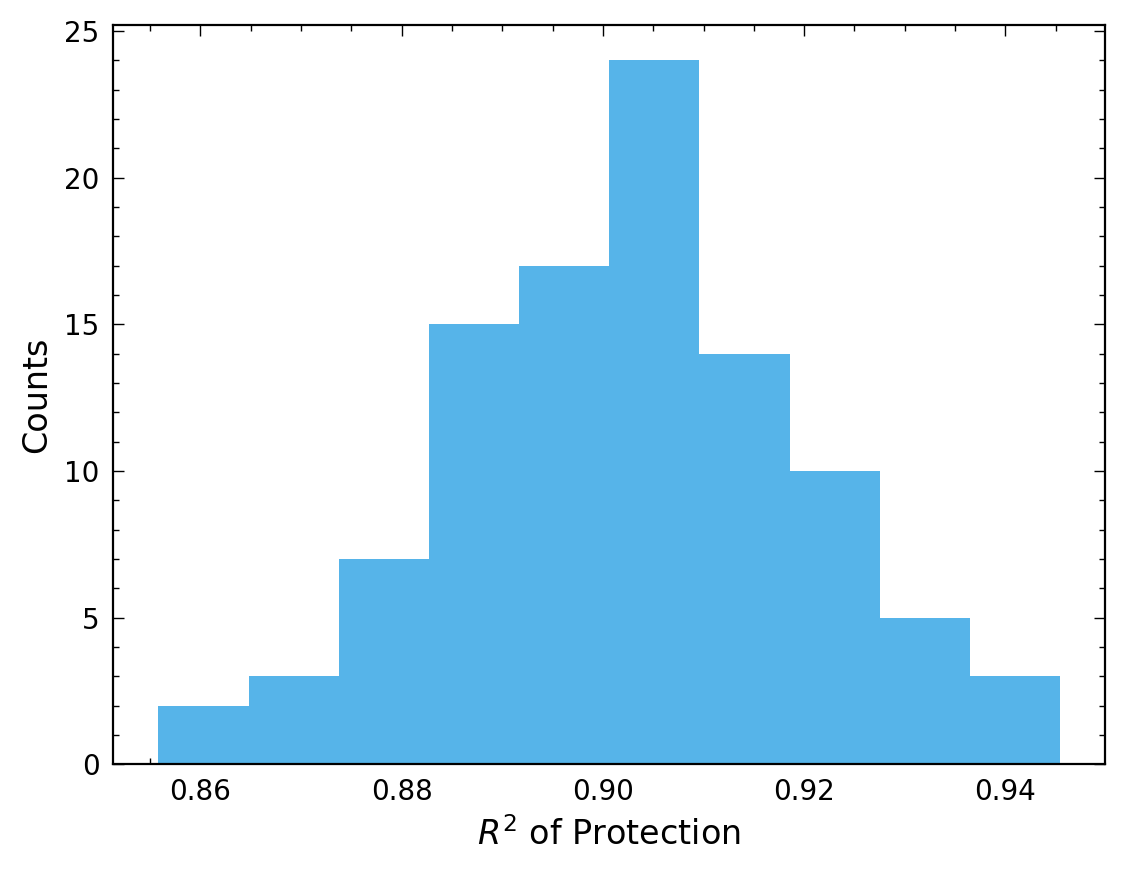

In [18]:
model_r_sq = 1 - impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].rmse**2/impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_std**2
plt.hist(model_r_sq);
plt.xlabel(r"$R^2$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

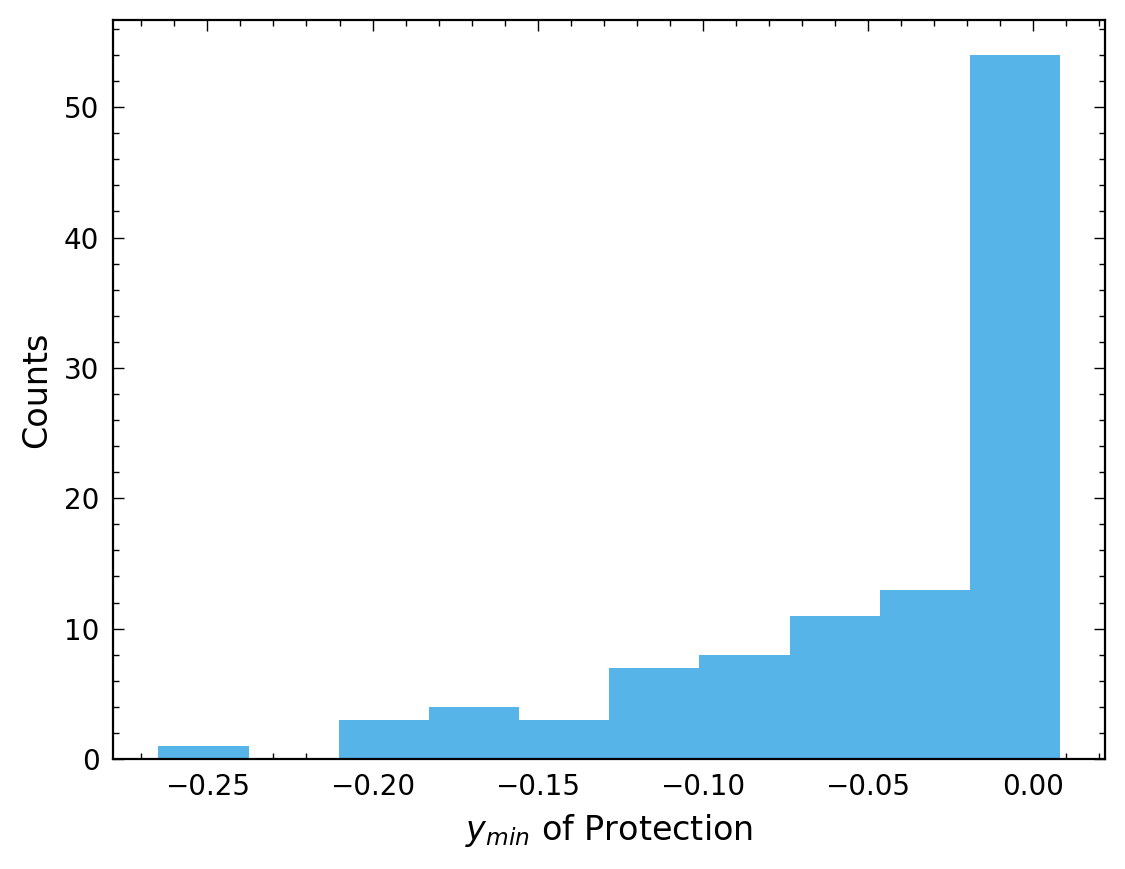

In [19]:
plt.hist(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_min);
plt.xlabel(r"$y_{min}$ of "+perf_labels[perf])
plt.ylabel("Counts")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for protection/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high protection/toxicity in this module.

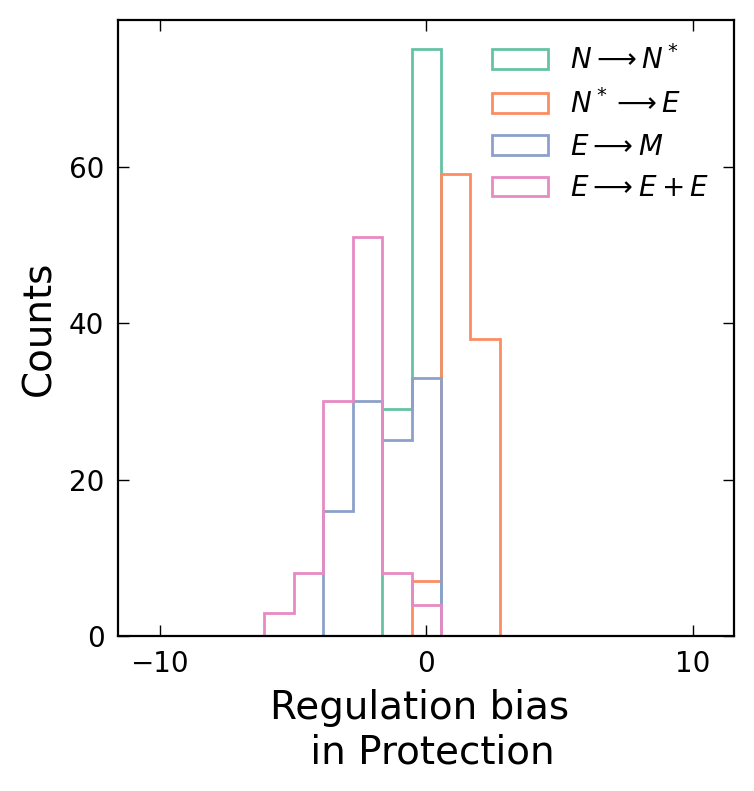

In [20]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 20), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

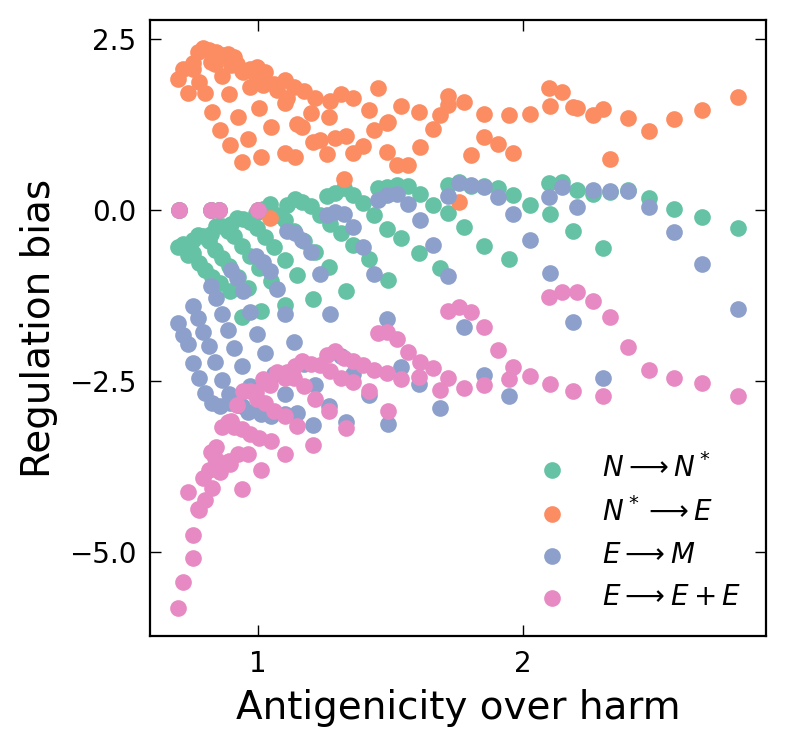

In [21]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]
    axs.scatter(data['antigenicity_over_harm'], data['intercept_'+r], label = module_labels[i], c = cmap_colors[i])

axs.legend(fontsize = 10, ncol = 1)

axs.set_ylabel("Regulation bias", fontsize = 14)
axs.set_xlabel("Antigenicity over harm", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

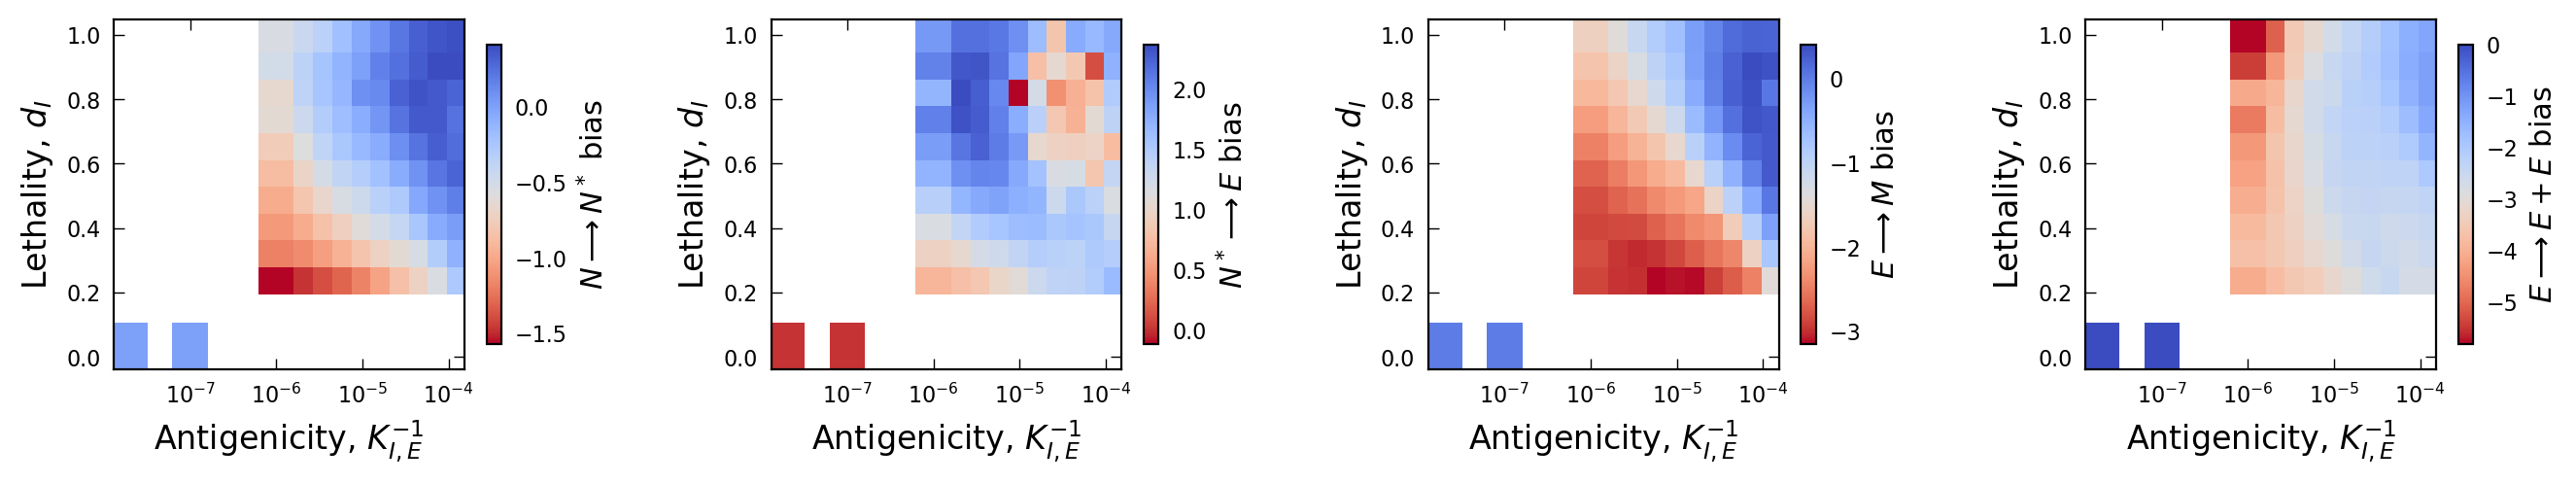

In [22]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{I,E}^{-1}$", "Lethality, "+r"$d_{I}$"]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

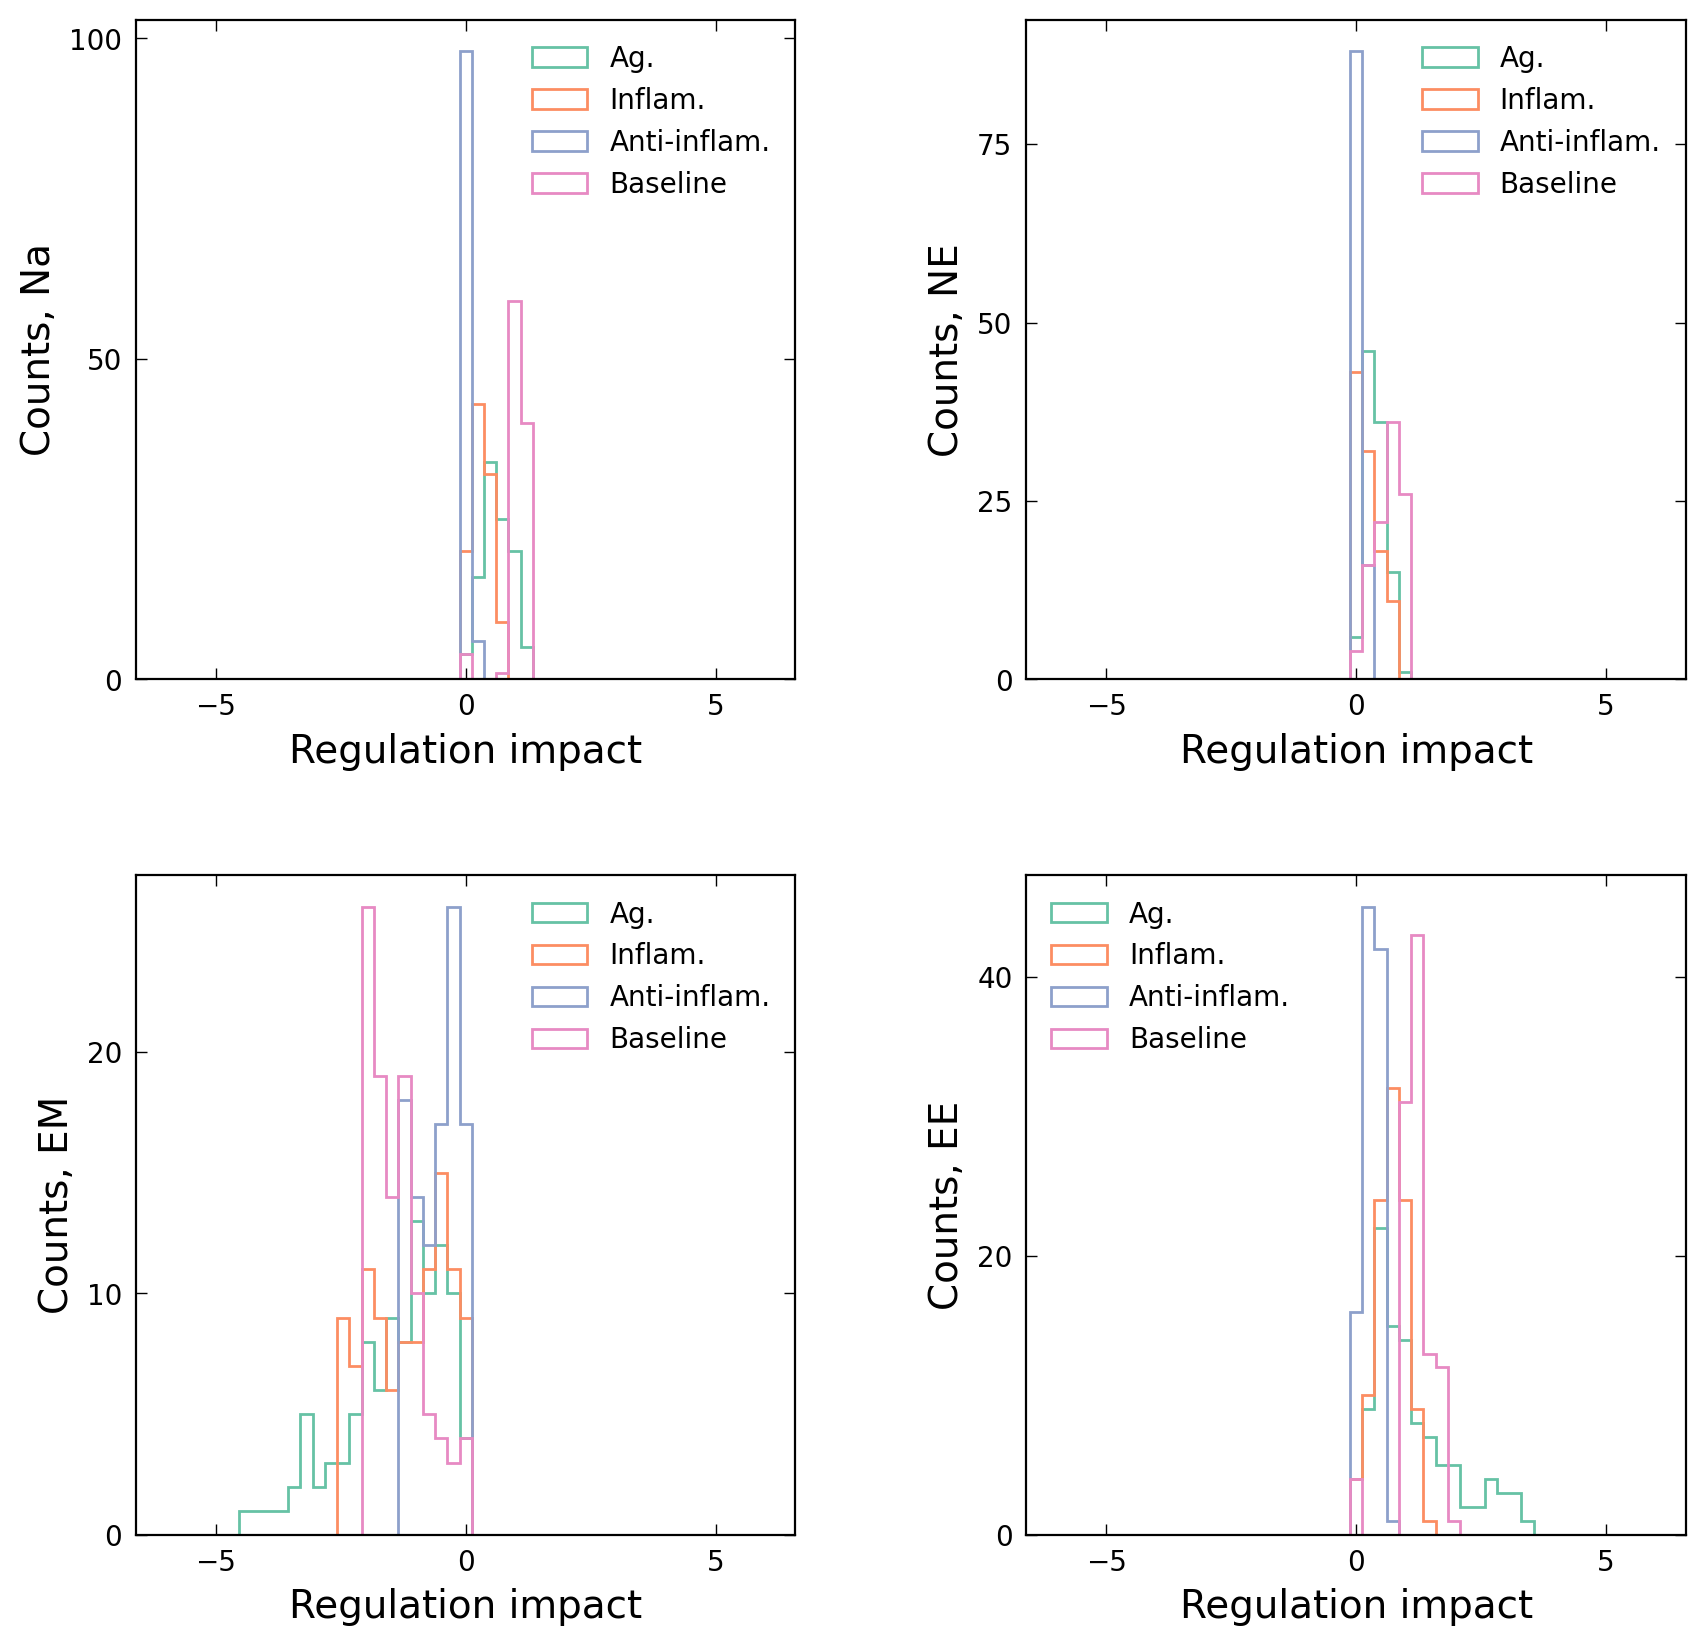

In [25]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-2.0*psi_max, 2.0*psi_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+modules[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [16]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == 0.0)*(impact_data['K_EH'] == K_EH)])

,y_max,y_min,intercept_Na,intercept_NE,intercept_EM,intercept_EE,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,sigma_y_max,sigma_y_min,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
1,5.910567,2.550153e-39,1.641243,2.662210,-2.462319,-3.987736,1.438201,0.251485,0.610627,2.219896,0.630542,0.151028,0.423007,0.995897,-1.198544,-0.042439,-1.589269,-1.950130,0.898069,0.058666,1.028146,1.550489,0.007608,0.000429,0.006429,0.009143,0.007440,0.009596,0.005897,0.003694,0.004079,0.007215,0.003420,0.002894,0.003131,0.003007,0.004002,0.002702,0.004759,0.004743,0.003415,0.001861,0.003772,0.005074,0.01,10000000.0,0.0,50000.0,300.0,10000000.0,0.233382,5.250549,0.0,0.000526,1.0,0.217595,0.868531,0.0,0.672736,0.060883,0.109833,0.999456
6,3.539552,8.677195e-17,0.025182,1.545383,-2.988261,-8.753002,0.397952,0.168580,0.614326,2.070318,0.166151,0.025561,0.468802,0.932588,-0.350182,-0.007760,-1.042681,-1.780776,0.362022,0.020974,1.043582,2.425466,0.003806,0.000100,0.002188,0.004347,0.006907,0.015954,0.002748,0.002344,0.003191,0.007763,0.001720,0.001691,0.001918,0.001839,0.001783,0.001624,0.002782,0.003808,0.001412,0.001215,0.002393,0.004529,0.01,50000000.0,0.0,50000.0,300.0,10000000.0,0.056832,3.311465,0.0,0.000000,1.0,0.053209,0.299781,0.0,0.179787,0.060883,0.034818,0.850787
11,5.636672,2.931641e-39,1.921092,2.611035,-2.446584,-4.024316,1.309918,0.834337,0.597524,2.082567,0.555531,0.442600,0.345795,0.970589,-1.154061,-0.166319,-1.550144,-1.938311,0.866540,0.198147,1.035632,1.541888,0.007985,0.000444,0.008385,0.009751,0.007947,0.010070,0.005622,0.004642,0.004275,0.006552,0.003556,0.003389,0.003267,0.003170,0.004211,0.002935,0.005021,0.005073,0.003516,0.002088,0.004000,0.005294,0.05,10000000.0,0.0,50000.0,300.0,10000000.0,0.225960,5.040793,0.0,0.000561,1.0,0.224444,0.832895,0.0,0.650409,0.267120,0.108675,0.822509
16,3.387818,1.430667e-13,0.119537,1.538873,-2.977861,-8.842322,0.365048,0.438720,0.616285,1.959467,0.155838,0.097236,0.444188,0.924848,-0.341967,-0.039797,-1.022043,-1.775421,0.355146,0.079455,1.047241,2.451253,0.003651,0.000097,0.002222,0.004330,0.006848,0.016274,0.002533,0.002681,0.003055,0.006806,0.001707,0.001690,0.001886,0.001820,0.001771,0.001622,0.002740,0.003780,0.001415,0.001232,0.002419,0.004617,0.05,50000000.0,0.0,50000.0,300.0,10000000.0,0.055090,3.120906,0.0,0.000000,1.0,0.051254,0.288780,0.0,0.172502,0.267120,0.034237,0.700161
